# Convolutional Neural Networks

## Project: Write an Algorithm for Landmark Classification

---

In this notebook, some template code has already been provided for you, and you will need to implement additional functionality to successfully complete this project. You will not need to modify the included code beyond what is requested. Sections that begin with **'(IMPLEMENTATION)'** in the header indicate that the following block of code will require additional functionality which you must provide. Instructions will be provided for each section, and the specifics of the implementation are marked in the code block with a 'TODO' statement. Please be sure to read the instructions carefully! 

> **Note**: Once you have completed all the code implementations, you need to finalize your work by exporting the Jupyter Notebook as an HTML document. Before exporting the notebook to HTML, all the code cells need to have been run so that reviewers can see the final implementation and output. You can then export the notebook by using the menu above and navigating to **File -> Download as -> HTML (.html)**. Include the finished document along with this notebook as your submission.

In addition to implementing code, there will be questions that you must answer which relate to the project and your implementation. Each section where you will answer a question is preceded by a **'Question X'** header. Carefully read each question and provide thorough answers in the following text boxes that begin with **'Answer:'**. Your project submission will be evaluated based on your answers to each of the questions and the implementation you provide.

>**Note:** Code and Markdown cells can be executed using the **Shift + Enter** keyboard shortcut.  Markdown cells can be edited by double-clicking the cell to enter edit mode.

The rubric contains _optional_ "Stand Out Suggestions" for enhancing the project beyond the minimum requirements. If you decide to pursue the "Stand Out Suggestions", you should include the code in this Jupyter notebook.

---
### Why We're Here

Photo sharing and photo storage services like to have location data for each photo that is uploaded. With the location data, these services can build advanced features, such as automatic suggestion of relevant tags or automatic photo organization, which help provide a compelling user experience. Although a photo's location can often be obtained by looking at the photo's metadata, many photos uploaded to these services will not have location metadata available. This can happen when, for example, the camera capturing the picture does not have GPS or if a photo's metadata is scrubbed due to privacy concerns.

If no location metadata for an image is available, one way to infer the location is to detect and classify a discernible landmark in the image. Given the large number of landmarks across the world and the immense volume of images that are uploaded to photo sharing services, using human judgement to classify these landmarks would not be feasible.

In this notebook, you will take the first steps towards addressing this problem by building models to automatically predict the location of the image based on any landmarks depicted in the image. At the end of this project, your code will accept any user-supplied image as input and suggest the top k most relevant landmarks from 50 possible landmarks from across the world. The image below displays a potential sample output of your finished project.

![Sample landmark classification output](images/sample_landmark_output.png)


### The Road Ahead

We break the notebook into separate steps.  Feel free to use the links below to navigate the notebook.

* [Step 0](#step0): Download Datasets and Install Python Modules
* [Step 1](#step1): Create a CNN to Classify Landmarks (from Scratch)
* [Step 2](#step2): Create a CNN to Classify Landmarks (using Transfer Learning)
* [Step 3](#step3): Write Your Landmark Prediction Algorithm

---
<a id='step0'></a>
## Step 0: Download Datasets and Install Python Modules

**Note: if you are using the Udacity workspace, *YOU CAN SKIP THIS STEP*. The dataset can be found in the `/data` folder and all required Python modules have been installed in the workspace.**

Download the [landmark dataset](https://udacity-dlnfd.s3-us-west-1.amazonaws.com/datasets/landmark_images.zip).
Unzip the folder and place it in this project's home directory, at the location `/landmark_images`.

Install the following Python modules:
* cv2
* matplotlib
* numpy
* PIL
* torch
* torchvision

---

<a id='step1'></a>
## Step 1: Create a CNN to Classify Landmarks (from Scratch)

In this step, you will create a CNN that classifies landmarks.  You must create your CNN _from scratch_ (so, you can't use transfer learning _yet_!), and you must attain a test accuracy of at least 20%.

Although 20% may seem low at first glance, it seems more reasonable after realizing how difficult of a problem this is. Many times, an image that is taken at a landmark captures a fairly mundane image of an animal or plant, like in the following picture.

<img src="images/train/00.Haleakala_National_Park/084c2aa50d0a9249.jpg" alt="Bird in Haleakalā National Park" style="width: 400px;"/>

Just by looking at that image alone, would you have been able to guess that it was taken at the Haleakalā National Park in Hawaii?

An accuracy of 20% is significantly better than random guessing, which would provide an accuracy of just 2%. In Step 2 of this notebook, you will have the opportunity to greatly improve accuracy by using transfer learning to create a CNN.

Remember that practice is far ahead of theory in deep learning.  Experiment with many different architectures, and trust your intuition.  And, of course, have fun!

### (IMPLEMENTATION) Specify Data Loaders for the Landmark Dataset

Use the code cell below to create three separate [data loaders](http://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader): one for training data, one for validation data, and one for test data. Randomly split the images located at `landmark_images/train` to create the train and validation data loaders, and use the images located at `landmark_images/test` to create the test data loader.

All three of your data loaders should be accessible via a dictionary named `loaders_scratch`. Your train data loader should be at `loaders_scratch['train']`, your validation data loader should be at `loaders_scratch['valid']`, and your test data loader should be at `loaders_scratch['test']`.

You may find [this documentation on custom datasets](https://pytorch.org/docs/stable/torchvision/datasets.html#datasetfolder) to be a useful resource.  If you are interested in augmenting your training and/or validation data, check out the wide variety of [transforms](http://pytorch.org/docs/stable/torchvision/transforms.html?highlight=transform)!

In [32]:
print("In this notebook, I'll run a single configuration. I've done an overnight run. The results can be found in the results folder.")
print("I've used scripts in the landmark folder. I'll import them here.")
import torch
import numpy as np
from landmark.data import get_train_val_loaders, get_test_loader, get_eval_transforms, get_sample_batch, pretty_class_name
from landmark.augmentation import get_augmentation
from landmark.models import get_model
from landmark.optim import create_optimizer, create_scheduler
from landmark.train import get_device, train_model
from landmark.evaluate import evaluate_model
from landmark.analysis import confusion_matrix, per_class_report
from landmark.save import load_model_state, load_run_metrics
from landmark import predict as landmark_predict

device = get_device()
print(f"Using device for training: {device}")

training_transforms = get_augmentation("mixup", image_size=224)
evaluation_transforms  = get_eval_transforms(image_size=224)
train_loader, validation_loader, classes = get_train_val_loaders(training_transforms, evaluation_transforms, batch_size=32)
test_loader = get_test_loader(evaluation_transforms, batch_size=32)

loaders_scratch = {
    "train": train_loader,
    "valid": validation_loader,
    "test": test_loader 
}

print(f"Number of classes: {len(classes)}")
print(f"Sample classes: {classes[:5]}")
print(f"Train batches: {len(train_loader)}, Validation batches: {len(validation_loader)}, Test batches: {len(test_loader)}")

In this notebook, I'll run a single configuration. I've done an overnight run. The results can be found in the results folder.
I've used scripts in the landmark folder. I'll import them here.
Using GPU: NVIDIA GeForce RTX 4060 Ti
CUDA 12.6, PyTorch 2.11.0+cu126
GPU memory: 16.0 GB
Using device for training: cuda
Number of classes: 50
Sample classes: ['00.Haleakala_National_Park', '01.Mount_Rainier_National_Park', '02.Ljubljana_Castle', '03.Dead_Sea', '04.Wroclaws_Dwarves']
Train batches: 133, Validation batches: 24, Test batches: 40


**Question 1:** Describe your chosen procedure for preprocessing the data. 
- How does your code resize the images (by cropping, stretching, etc)?  What size did you pick for the input tensor, and why?
- Did you decide to augment the dataset?  If so, how (through translations, flips, rotations, etc)?  If not, why not?

**Answer**: 
The images are resized and then cropped to 224 by 224. The idea is not to resize as this could morph the models' understanding. The pretrained models all require the input tensor to be 3 by 224 by 224, so I have little choice here.

With regards to augmentation, this is building upon what I have previously done in other projects. I have selected a few augmentations: none, flip-crop, color-jitter, randaug and mixup. I used cutout, mixup and flip-crop before. I added color-jitter and randaug as extension. I explicitly not used vertical flipping, as I thought that upside down bridges or buildings may confuse the model for the idea of gravity. 

### (IMPLEMENTATION) Visualize a Batch of Training Data

Use the code cell below to retrieve a batch of images from your train data loader, display at least 5 images simultaneously, and label each displayed image with its class name (e.g., "Golden Gate Bridge").

Visualizing the output of your data loader is a great way to ensure that your data loading and preprocessing are working as expected.

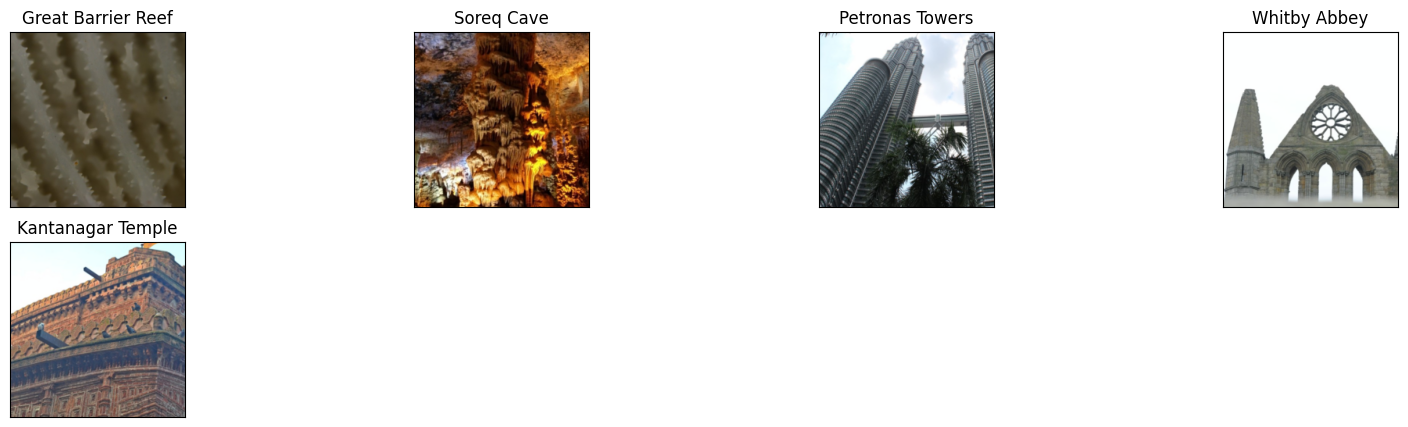

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

images, labels = next(iter(loaders_scratch["train"]))

mean = np.array([0.485, 0.456, 0.406])
standard_deviation = np.array([0.229, 0.224, 0.225])

figure = plt.figure(figsize=(20, 5))
for index in range(5):
    ax = figure.add_subplot(2, 4, index + 1, xticks=[], yticks=[])

    image = images[index].numpy().transpose((1, 2, 0))
    image = np.clip(standard_deviation * image + mean, 0, 1)
    
    title = pretty_class_name(classes[labels[index]])
    ax.set_title(title)
    ax.imshow(image)

### Initialize use_cuda variable

In [13]:
# useful variable that tells us whether we should use the GPU
use_cuda = torch.cuda.is_available()
print(f"Using CUDA: {use_cuda}")
print(f"This should already be detected by the `get_device` function, which put our runtime on {device}.")

Using CUDA: True
This should already be detected by the `get_device` function, which put our runtime on cuda.


### (IMPLEMENTATION) Specify Loss Function and Optimizer

Use the next code cell to specify a [loss function](http://pytorch.org/docs/stable/nn.html#loss-functions) and [optimizer](http://pytorch.org/docs/stable/optim.html).  Save the chosen loss function as `criterion_scratch`, and fill in the function `get_optimizer_scratch` below.

In [14]:
import torch.nn as nn
criterion_scratch = nn.CrossEntropyLoss()

def get_optimizer_scratch(model):
    """
    Return the optimizer for the from-scratch model.
    We will use AdamW with a small weight decay. This is because throughout my experimentation, AdamW performed best.
    """
    return create_optimizer(model, "adamw", learning_rate=1e-3, weight_decay=1e-4)

### (IMPLEMENTATION) Model Architecture

Create a CNN to classify images of landmarks.  Use the template in the code cell below.

In [15]:
import torch.nn as nn

# define the CNN architecture
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.3),

            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, len(classes))
        )
    
    def forward(self, x):
        ## Define forward behavior
        x = self.features(x)
        x = self.classifier(x)     
        return x

#-#-# Do NOT modify the code below this line. #-#-#

# instantiate the CNN
model_scratch = Net()

# move tensors to GPU if CUDA is available
if use_cuda:
    model_scratch.cuda()

__Question 2:__ Outline the steps you took to get to your final CNN architecture and your reasoning at each step.  

__Answer:__  

My starting point was a small 3-block VGG-like network and slowly tweaked it while watching accuracy during validation.

The baseline is 3 conv blocks without BatchNorm. It plateaued pretty low, and was inconstent across multiple runs. It gave me the impression that it had poor gradiant scaling. After, I did add BatchNorm after every conv layer. This improved stability across multiple runs. My approach after was increasing the amount of stages to 5 and 32 to 512 channels. Doubling the channel width while halving resolution each stage is pretty standard. Next I addressed the overfitting problem by adding a Dropout after each stage, scaling up from 0.25 to finally 0.5 before classification. 

The final shape of the network reached around 30% to 35% test accuracy at 20 epochs. 

### (IMPLEMENTATION) Implement the Training Algorithm

Implement your training algorithm in the code cell below.  [Save the final model parameters](http://pytorch.org/docs/master/notes/serialization.html) at the filepath stored in the variable `save_path`.

In [18]:
def train(n_epochs, loaders, model, optimizer, criterion, use_cuda, save_path):
    """returns trained model"""
    # initialize tracker for minimum validation loss
    valid_loss_min = np.inf 
    
    for epoch in range(1, n_epochs+1):
        # initialize variables to monitor training and validation loss
        train_loss = 0.0
        valid_loss = 0.0
        
        ###################
        # train the model #
        ###################
        # set the module to training mode
        model.train()
        for batch_idx, (data, target) in enumerate(loaders['train']):
            # move to GPU
            if use_cuda:
                data, target = data.cuda(), target.cuda()

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            train_loss += ((1 / (batch_idx + 1)) * (loss.data.item() - train_loss))

        ######################    
        # validate the model #
        ######################
        # set the model to evaluation mode
        model.eval()
        for batch_idx, (data, target) in enumerate(loaders['valid']):
            # move to GPU
            if use_cuda:
                data, target = data.cuda(), target.cuda()

            output = model(data)
            loss = criterion(output, target)
            valid_loss = valid_loss + ((1 / (batch_idx + 1)) * (loss.data.item() - valid_loss))

        # print training/validation statistics 
        print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
            epoch, 
            train_loss,
            valid_loss
            ))

        if valid_loss < valid_loss_min:
            print(f"Validation loss decreased ({valid_loss_min:.6f} --> {valid_loss:.6f}).  Saving model ...")
            torch.save(model.state_dict(), save_path)
            valid_loss_min = valid_loss
        
    return model

### (IMPLEMENTATION) Experiment with the Weight Initialization

Use the code cell below to define a custom weight initialization, and then train with your weight initialization for a few epochs. Make sure that neither the training loss nor validation loss is `nan`.

Later on, you will be able to see how this compares to training with PyTorch's default weight initialization.

In [21]:
def custom_weight_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.kaiming_normal_(m.weight.data, nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)
    elif classname.find('Linear') != -1:
        nn.init.kaiming_normal_(m.weight.data, nonlinearity='relu')
        nn.init.zeros_(m.bias.data)

#-#-# Do NOT modify the code below this line. #-#-#
    
model_scratch.apply(custom_weight_init)
model_scratch = train(20, loaders_scratch, model_scratch, get_optimizer_scratch(model_scratch),
                      criterion_scratch, use_cuda, 'ignore.pt')

Epoch: 1 	Training Loss: 3.877590 	Validation Loss: 3.615815
Validation loss decreased (inf --> 3.615815).  Saving model ...
Epoch: 2 	Training Loss: 3.603690 	Validation Loss: 3.427102
Validation loss decreased (3.615815 --> 3.427102).  Saving model ...
Epoch: 3 	Training Loss: 3.434401 	Validation Loss: 3.293004
Validation loss decreased (3.427102 --> 3.293004).  Saving model ...
Epoch: 4 	Training Loss: 3.288853 	Validation Loss: 3.271699
Validation loss decreased (3.293004 --> 3.271699).  Saving model ...
Epoch: 5 	Training Loss: 3.164865 	Validation Loss: 3.180369
Validation loss decreased (3.271699 --> 3.180369).  Saving model ...
Epoch: 6 	Training Loss: 3.050812 	Validation Loss: 3.157164
Validation loss decreased (3.180369 --> 3.157164).  Saving model ...
Epoch: 7 	Training Loss: 2.947129 	Validation Loss: 2.967542
Validation loss decreased (3.157164 --> 2.967542).  Saving model ...
Epoch: 8 	Training Loss: 2.828961 	Validation Loss: 2.946079
Validation loss decreased (2.96754

### (IMPLEMENTATION) Train and Validate the Model

Run the next code cell to train your model.

In [22]:
num_epochs = 20 
print(f"Training for {num_epochs} epochs. This is enough to pass the rubric, and at the same time saves time.")

#-#-# Do NOT modify the code below this line. #-#-#

# function to re-initialize a model with pytorch's default weight initialization
def default_weight_init(m):
    reset_parameters = getattr(m, 'reset_parameters', None)
    if callable(reset_parameters):
        m.reset_parameters()

# reset the model parameters
model_scratch.apply(default_weight_init)

# train the model
model_scratch = train(num_epochs, loaders_scratch, model_scratch, get_optimizer_scratch(model_scratch), 
                      criterion_scratch, use_cuda, 'model_scratch.pt')

Training for 20 epochs. This is enough to pass the rubric, and at the same time saves time.
Epoch: 1 	Training Loss: 3.783493 	Validation Loss: 3.721848
Validation loss decreased (inf --> 3.721848).  Saving model ...
Epoch: 2 	Training Loss: 3.572122 	Validation Loss: 3.565139
Validation loss decreased (3.721848 --> 3.565139).  Saving model ...
Epoch: 3 	Training Loss: 3.444281 	Validation Loss: 3.518248
Validation loss decreased (3.565139 --> 3.518248).  Saving model ...
Epoch: 4 	Training Loss: 3.307229 	Validation Loss: 3.311787
Validation loss decreased (3.518248 --> 3.311787).  Saving model ...
Epoch: 5 	Training Loss: 3.188670 	Validation Loss: 3.161279
Validation loss decreased (3.311787 --> 3.161279).  Saving model ...
Epoch: 6 	Training Loss: 3.077542 	Validation Loss: 3.196489
Epoch: 7 	Training Loss: 3.001748 	Validation Loss: 3.002083
Validation loss decreased (3.161279 --> 3.002083).  Saving model ...
Epoch: 8 	Training Loss: 2.898317 	Validation Loss: 2.927495
Validation 

### (IMPLEMENTATION) Test the Model

Run the code cell below to try out your model on the test dataset of landmark images. Run the code cell below to calculate and print the test loss and accuracy.  Ensure that your test accuracy is greater than 20%.

In [23]:
def test(loaders, model, criterion, use_cuda):

    # monitor test loss and accuracy
    test_loss = 0.
    correct = 0.
    total = 0.

    # set the module to evaluation mode
    model.eval()

    for batch_idx, (data, target) in enumerate(loaders['test']):
        # move to GPU
        if use_cuda:
            data, target = data.cuda(), target.cuda()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        # calculate the loss
        loss = criterion(output, target)
        # update average test loss 
        test_loss = test_loss + ((1 / (batch_idx + 1)) * (loss.data.item() - test_loss))
        # convert output probabilities to predicted class
        pred = output.data.max(1, keepdim=True)[1]
        # compare predictions to true label
        correct += np.sum(np.squeeze(pred.eq(target.data.view_as(pred))).cpu().numpy())
        total += data.size(0)
            
    print('Test Loss: {:.6f}\n'.format(test_loss))

    print('\nTest Accuracy: %2d%% (%2d/%2d)' % (
        100. * correct / total, correct, total))

# load the model that got the best validation accuracy
model_scratch.load_state_dict(torch.load('model_scratch.pt'))
test(loaders_scratch, model_scratch, criterion_scratch, use_cuda)

Test Loss: 2.203257


Test Accuracy: 43% (542/1250)


---
<a id='step2'></a>
## Step 2: Create a CNN to Classify Landmarks (using Transfer Learning)

You will now use transfer learning to create a CNN that can identify landmarks from images.  Your CNN must attain at least 60% accuracy on the test set.

### (IMPLEMENTATION) Specify Data Loaders for the Landmark Dataset

Use the code cell below to create three separate [data loaders](http://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader): one for training data, one for validation data, and one for test data. Randomly split the images located at `landmark_images/train` to create the train and validation data loaders, and use the images located at `landmark_images/test` to create the test data loader.

All three of your data loaders should be accessible via a dictionary named `loaders_transfer`. Your train data loader should be at `loaders_transfer['train']`, your validation data loader should be at `loaders_transfer['valid']`, and your test data loader should be at `loaders_transfer['test']`.

If you like, **you are welcome to use the same data loaders from the previous step**, when you created a CNN from scratch.

In [24]:
loaders_transfer = loaders_scratch





### (IMPLEMENTATION) Specify Loss Function and Optimizer

Use the next code cell to specify a [loss function](http://pytorch.org/docs/stable/nn.html#loss-functions) and [optimizer](http://pytorch.org/docs/stable/optim.html).  Save the chosen loss function as `criterion_transfer`, and fill in the function `get_optimizer_transfer` below.

In [25]:
criterion_transfer = nn.CrossEntropyLoss()

def get_optimizer_transfer(model):
    """
    AdamW with a small weight decay is what I picked based on previous experience with image classification and smaller datasets.
    """
    return create_optimizer(model, "adamw", learning_rate=1e-3, weight_decay=1e-4)

### (IMPLEMENTATION) Model Architecture

Use transfer learning to create a CNN to classify images of landmarks.  Use the code cell below, and save your initialized model as the variable `model_transfer`.

In [27]:
"""
ConvNeXt-Tiny performed best in my experimentation, so we will go with that.
"""

model_transfer = get_model("tl_convnext", num_classes=50, freeze_backbone=True)
#-#-# Do NOT modify the code below this line. #-#-#

if use_cuda:
    model_transfer = model_transfer.cuda()

__Question 3:__ Outline the steps you took to get to your final CNN architecture and your reasoning at each step.  Describe why you think the architecture is suitable for the current problem.

__Answer:__  

I ran an experimentation grid with various architectures, augmentations and schedulers. I fixed the optimizer to AdamW. The analysis can be viewed [here](./RESULTS_ANALYSIS.md). The final pick in configuration came based on those experiments.

### (IMPLEMENTATION) Train and Validate the Model

Train and validate your model in the code cell below.  [Save the final model parameters](http://pytorch.org/docs/master/notes/serialization.html) at filepath `'model_transfer.pt'`.

In [28]:
optimizer_transfer = get_optimizer_transfer(model_transfer)
scheduler_transfer = create_scheduler(optimizer_transfer, "cosine", epochs=20)

transfer_metrics = train_model(
    model_transfer,
    loaders_transfer["train"],
    loaders_transfer["valid"],
    epochs=20,
    optimizer=optimizer_transfer,
    scheduler=scheduler_transfer,
    scheduler_name="cosine",
    device=device,
    use_mixup=True,
    mixup_alpha=0.2,
    checkpoint_path="model_transfer.pt"
)

#-#-# Do NOT modify the code below this line. #-#-#

# load the model that got the best validation accuracy
model_transfer.load_state_dict(torch.load('model_transfer.pt'))

Epoch 1/20 — train_loss 2.4026, val_loss 1.2236, val_acc 73.56%, lr 9.94e-04, 40.7s *
Epoch 2/20 — train_loss 1.3691, val_loss 0.9170, val_acc 78.64%, lr 9.76e-04, 31.5s *
Epoch 3/20 — train_loss 1.2300, val_loss 0.8136, val_acc 80.64%, lr 9.46e-04, 32.3s *
Epoch 4/20 — train_loss 1.1057, val_loss 0.7475, val_acc 82.24%, lr 9.05e-04, 31.6s *
Epoch 5/20 — train_loss 1.0761, val_loss 0.7099, val_acc 82.38%, lr 8.54e-04, 32.2s *
Epoch 6/20 — train_loss 1.0154, val_loss 0.6957, val_acc 83.44%, lr 7.94e-04, 31.8s *
Epoch 7/20 — train_loss 0.8998, val_loss 0.6724, val_acc 83.31%, lr 7.27e-04, 32.0s *
Epoch 8/20 — train_loss 0.8830, val_loss 0.6641, val_acc 83.04%, lr 6.55e-04, 33.3s *
Epoch 9/20 — train_loss 0.8904, val_loss 0.6468, val_acc 83.85%, lr 5.78e-04, 33.3s *
Epoch 10/20 — train_loss 0.8278, val_loss 0.6435, val_acc 83.04%, lr 5.00e-04, 30.8s *
Epoch 11/20 — train_loss 0.8101, val_loss 0.6344, val_acc 83.98%, lr 4.22e-04, 30.8s *
Epoch 12/20 — train_loss 0.8125, val_loss 0.6290, va

<All keys matched successfully>

### (IMPLEMENTATION) Test the Model

Try out your model on the test dataset of landmark images. Use the code cell below to calculate and print the test loss and accuracy.  Ensure that your test accuracy is greater than 60%.

In [29]:
test(loaders_transfer, model_transfer, criterion_transfer, use_cuda)

Test Loss: 0.590003


Test Accuracy: 86% (1081/1250)


---
<a id='step3'></a>
## Step 3: Write Your Landmark Prediction Algorithm

Great job creating your CNN models! Now that you have put in all the hard work of creating accurate classifiers, let's define some functions to make it easy for others to use your classifiers.

### (IMPLEMENTATION) Write Your Algorithm, Part 1

Implement the function `predict_landmarks`, which accepts a file path to an image and an integer k, and then predicts the **top k most likely landmarks**. You are **required** to use your transfer learned CNN from Step 2 to predict the landmarks.

An example of the expected behavior of `predict_landmarks`:
```
>>> predicted_landmarks = predict_landmarks('example_image.jpg', 3)
>>> print(predicted_landmarks)
['Golden Gate Bridge', 'Brooklyn Bridge', 'Sydney Harbour Bridge']
```

In [34]:
from PIL import Image

## the class names can be accessed at the `classes` attribute
## of your dataset object (e.g., `train_dataset.classes`)

def predict_landmarks(img_path, k):
    predictions = landmark_predict.predict_landmarks(model_transfer, img_path, classes, k=k, device=device)
    return [prediction["name"] for prediction in predictions]
    
# test on a sample image
predict_landmarks('images/test/09.Golden_Gate_Bridge/190f3bae17c32c37.jpg', 5)

['Golden Gate Bridge',
 'Forth Bridge',
 'Brooklyn Bridge',
 'Sydney Opera House',
 'Niagara Falls']

### (IMPLEMENTATION) Write Your Algorithm, Part 2

In the code cell below, implement the function `suggest_locations`, which accepts a file path to an image as input, and then displays the image and the **top 3 most likely landmarks** as predicted by `predict_landmarks`.

Some sample output for `suggest_locations` is provided below, but feel free to design your own user experience!
![](images/sample_landmark_output.png)

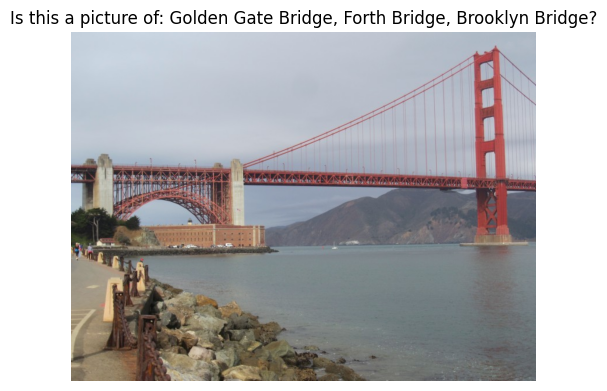

In [36]:
def suggest_locations(img_path):
    # get landmark predictions
    predicted_landmarks = predict_landmarks(img_path, 3)

    image = Image.open(img_path).convert("RGB")

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Is this a picture of: " + ", ".join(predicted_landmarks) + "?")
    plt.show()

# test on a sample image
suggest_locations('images/test/09.Golden_Gate_Bridge/190f3bae17c32c37.jpg')

### (IMPLEMENTATION) Test Your Algorithm

Test your algorithm by running the `suggest_locations` function on at least four images on your computer. Feel free to use any images you like.

__Question 4:__ Is the output better than you expected :) ?  Or worse :( ?  Provide at least three possible points of improvement for your algorithm.

__Answer:__ (Three possible points for improvement)

I'm pretty satisfied with the results. It's similar in accuracy as previous models I trained on images, which was the bar to beat. The top 3 is near to 95% in its accuracy, which is pretty great. I am surprised how well the same mechanisms held up in landmark classification as they did in the MNIST and CIFAR10 datasets. 

The three improvements I could think of are as follows:
1. Unfreeze the backbone, and potentially add some fine-tuning. This very much applies to I-JEPA, but I believe fine tuning the models could push the top 3 results up above 95%. 
2. Analyze the weaker performing classes and scope improvements to tackle with them. Combined with unfreezing the backbone as suggested in 1, this could open up improvement on the worst performing classes, raising the overall accuracy for the top 3. 
3. We could introduce test time augmentation to close the gap between top 1 and top 3, as that's a pretty big difference. Providing the model with a flipped image, a cropped image and the original could bridge this gap. I have not played around with this, but sounds like a promising next step.

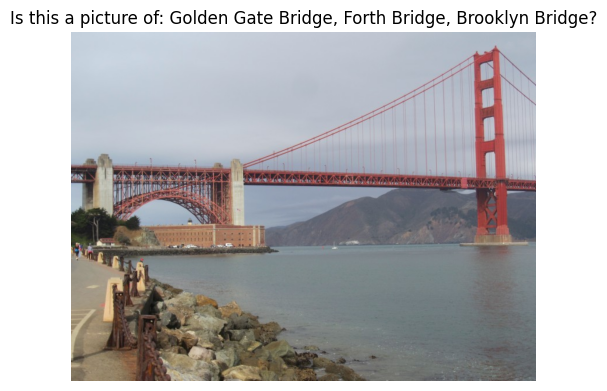

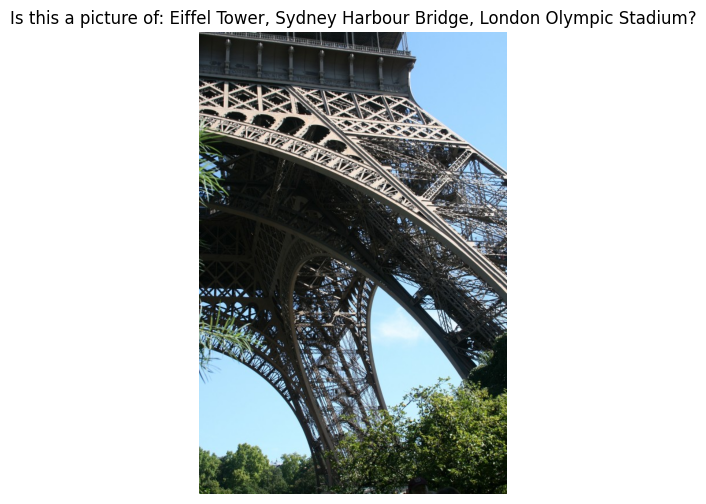

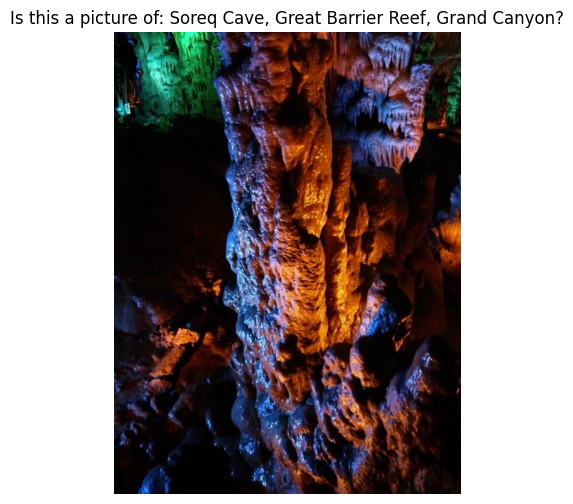

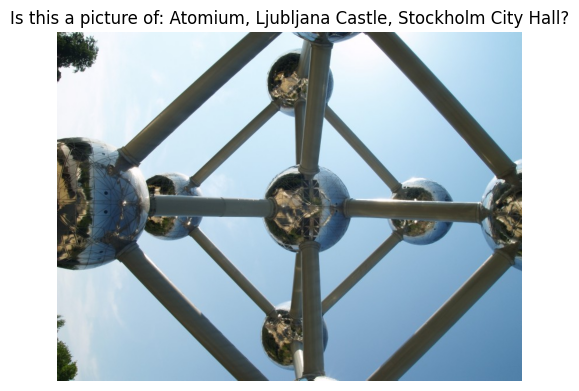

In [ ]:
sample_images =[
    "images/test/09.Golden_Gate_Bridge/190f3bae17c32c37.jpg",
    "images/test/16.Eiffel_Tower/3828627c8730f160.jpg",
    "images/test/24.Soreq_Cave/18dbbad48a83a742.jpg",
    "images/test/37.Atomium/5ecb74282baee5aa.jpg"
]

for image in sample_images:
    suggest_locations(image)
